In [1]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)
    
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.euclidean_vae as model
import lib.trainer as trainer
import lib.utils as utils

from configs.scruchy_configs import all_configs

In [2]:
torch.manual_seed(42)
np.random.seed(42)

----------------------------------------------------------------
Running exp1a_scrunchy with latent_dim=exp1a_scrunchy: low embedding dim + noise
----------------------------------------------------------------
Trainer successfully initialized.
Training the gaussianVAE model.
Epoch 1/10, Train Loss: 2.6598, Test Loss: 0.5009
--------------------------------------------------
Epoch 2/10, Train Loss: 0.3871, Test Loss: 0.1185
--------------------------------------------------
Epoch 3/10, Train Loss: 0.0165, Test Loss: 0.0018
--------------------------------------------------
Epoch 4/10, Train Loss: 0.0014, Test Loss: 0.0011
--------------------------------------------------
Epoch 5/10, Train Loss: 0.0009, Test Loss: 0.0009
--------------------------------------------------
Epoch 6/10, Train Loss: 0.0007, Test Loss: 0.0005
--------------------------------------------------
Epoch 7/10, Train Loss: 0.0005, Test Loss: 0.0004
--------------------------------------------------
Epoch 8/10, Trai

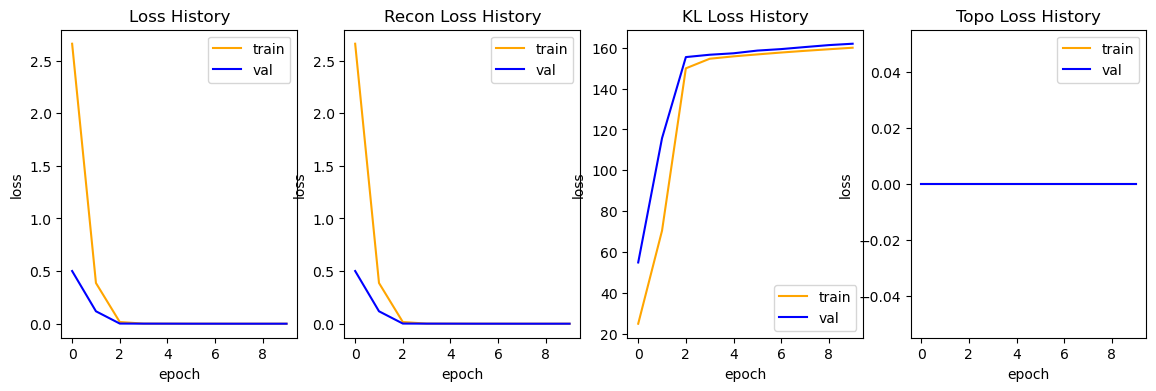

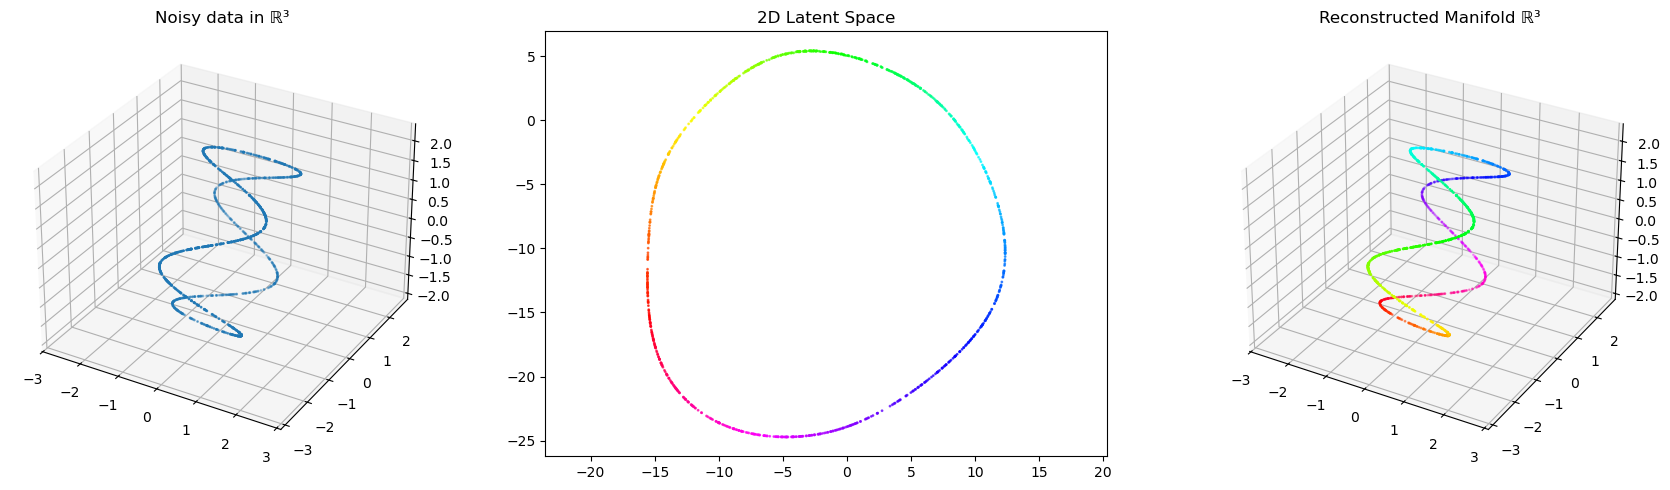

Forwarding data through model...
Computing learned curvature...
Forwarding data through model...
Starting actual computation...


KeyboardInterrupt: 

In [3]:
for name, config in all_configs.items():
    print("----------------------------------------------------------------")
    print(f"Running {name} with latent_dim={config.experiment}")
    print("----------------------------------------------------------------")
    data_loader = dataloader.load_synthetic_ds(config)
    train_loader, test_loader = data_loader
    vae_model = model.EuclideanVAE(config)
    optimizer = optim.Adam(vae_model.parameters(), lr=config.learning_rate)
    history = trainer.MVAETrainer(vae_model, data_loader, optimizer, config).train()
    utils.show_training_history(history)
    utils.plot_data_latents_recon(vae_model, test_loader, "cpu", 6000)
    utils.plot_empiric_curvature(config=config, model=vae_model, test_loader=train_loader)
    utils.plot_empiric_curvature(config=config, model=vae_model, test_loader=test_loader)